# Pipeline 3 — Temporal Particle Tracking End-to-End Test

This notebook processes a multi-frame sequence through the full Pipeline 3:
- Frame 0: Pipeline 1 cold-start (BestFirstSearcher)
- Frame 1+: IMU-predicted particle-guided two-pass search + meta-tile + semantic confirmation

Outputs: JSONL logs, meta-tiles, trajectory CSV, summary metrics.

In [1]:
# Cell 1 — Setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import config
from src.tile_utils import TileLoader, haversine_distance
from src.image_utils import load_image
from src.geometric_matcher import initialize_matcher
from src.semantic_model import load_semantic_model
from src.temporal_searcher import TemporalSearcher
from src.ekf_ins import preprocess_imu_csv

config.ensure_output_dirs()
print('Setup complete')

Setup complete


In [2]:
# Cell 2 — Load Video Sequence & IMU data + EKF preprocessing
from src.ekf_ins import preprocess_imu_csv
from src.tile_utils import tile_to_latlon

# Run Error-State EKF to get dead-reckoned positions
imu_log = preprocess_imu_csv(config.IMU_CSV_PATH)
print(f'IMU log: {len(imu_log)} rows')
print(f'Columns: {imu_log.columns.tolist()}')

# Build frame list: match CSV timestamps to frame files
frame_dir = config.QUERY_FRAMES_DIR
frame_files = sorted(frame_dir.glob('frame_*.jpg'))
print(f'Found {len(frame_files)} frames in {frame_dir}')

# Map rounded timestamp -> frame path
frame_map = {}
for fp in frame_files:
    ts_str = fp.stem.replace('frame_', '')
    try:
        ts = float(ts_str)
        frame_map[round(ts, 3)] = fp
    except ValueError:
        continue

# Auto-detect START_ROW: first row where GPS is inside the reference map tile bounds
# In TMS: higher Y = more north. tile_to_latlon returns SW corner for integer tiles.
south_lat, west_lon = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)
north_lat, _ = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MAX + 1, config.TMS_ZOOM_LEVEL)
_, east_lon = tile_to_latlon(config.TILE_X_MAX + 1, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)

map_bounds = {
    'lat_min': south_lat,
    'lat_max': north_lat,
    'lon_min': west_lon,
    'lon_max': east_lon,
}
print(f'Reference map bounds: lat [{map_bounds["lat_min"]:.4f}, {map_bounds["lat_max"]:.4f}], '
      f'lon [{map_bounds["lon_min"]:.4f}, {map_bounds["lon_max"]:.4f}]')

START_ROW = 0
for idx in range(len(imu_log)):
    row = imu_log.iloc[idx]
    lat = row['gps_lat']
    lon = row['gps_lon']
    if (map_bounds['lat_min'] <= lat <= map_bounds['lat_max'] and
        map_bounds['lon_min'] <= lon <= map_bounds['lon_max']):
        START_ROW = idx
        break
print(f'Auto-detected START_ROW = {START_ROW} (first GPS inside reference map)')

NUM_FRAMES = 300

aligned = []
for idx in range(START_ROW, len(imu_log)):
    row = imu_log.iloc[idx]
    ts_rounded = round(row['timestamp'], 3)
    if ts_rounded in frame_map:
        aligned.append((idx, row['timestamp'], frame_map[ts_rounded]))
    if len(aligned) >= NUM_FRAMES:
        break

print(f'Aligned {len(aligned)} frame-IMU pairs (starting from row {START_ROW})')
if aligned:
    print(f'First: ts={aligned[0][1]:.3f}  Last: ts={aligned[-1][1]:.3f}')
    r0 = imu_log.iloc[aligned[0][0]]
    print(f'First frame GPS: ({r0["gps_lat"]:.6f}, {r0["gps_lon"]:.6f})')
    print(f'First frame EKF: ({r0["latitude_est"]:.6f}, {r0["longitude_est"]:.6f})')

IMU log: 970 rows
Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'gps_lat', 'gps_lon', 'gps_alt', 'pitch', 'bank', 'heading', 'pressure_altitude', 'barometer_pressure', 'heading_magnetic', 'magnetic_compass', 'airspeed_indicated', 'airspeed_true', 'ground_velocity', 'vertical_speed', 'ap_master', 'ap_alt_hold', 'ap_airspeed_hold', 'ap_nav_hold', 'throttle_pos', 'latitude_est', 'longitude_est', 'altitude_est', 'pos_n', 'pos_e', 'pos_d', 'vel_n', 'vel_e', 'vel_d', 'roll_deg', 'pitch_deg', 'yaw_deg', 'gyro_bias_x', 'gyro_bias_y', 'gyro_bias_z', 'wind_n', 'wind_e']
Found 969 frames in C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Logs_Run_20260321_162024\images_20260321_162024
Reference map bounds: lat [55.6807, 55.7364], lon [9.4812, 9.5636]
Auto-detected START_ROW = 430 (first GPS inside reference map)
Aligned 300 frame-IMU pairs (starting from row 430)
First: ts=199.325  Last: ts=334.797
First frame GPS: (55.680738, 9.558186)
First frame EKF:

In [3]:
# Cell 3 — Initialize Temporal Searcher
semantic_model = load_semantic_model(config.SEMANTIC_MODEL_PATH, config.DEVICE)
matcher = initialize_matcher(config.DEVICE, config.MAX_NUM_KEYPOINTS)
tile_loader = TileLoader(
    config.REFERENCE_TILES_DIR,
    config.REFERENCE_PRED_DIR,
    zoom=config.TMS_ZOOM_LEVEL,
    x_range=(config.TILE_X_MIN, config.TILE_X_MAX),
    y_range=(config.TILE_Y_MIN, config.TILE_Y_MAX),
)
print(f'Tiles available: {len(tile_loader.list_tiles())}')

searcher = TemporalSearcher(semantic_model, matcher, tile_loader, config)
print('TemporalSearcher initialized')

Tiles available: 3960
TemporalSearcher initialized


In [11]:
# Cell 2.5 — EKF Sanity Check: compare EKF estimates vs GPS ground truth
from src.tile_utils import haversine_distance

# Check EKF drift for aligned frames
ekf_errors = []
for csv_idx, ts, _ in aligned:
    row = imu_log.iloc[csv_idx]
    d = haversine_distance(row['latitude_est'], row['longitude_est'],
                           row['gps_lat'], row['gps_lon'])
    ekf_errors.append(d)

ekf_errors = np.array(ekf_errors)
print(f'EKF vs GPS drift (for {len(aligned)} aligned frames):')
print(f'  Mean:    {ekf_errors.mean():.1f} m')
print(f'  Median:  {np.median(ekf_errors):.1f} m')
print(f'  Min:     {ekf_errors.min():.1f} m')
print(f'  Max:     {ekf_errors.max():.1f} m')
print(f'  Std:     {ekf_errors.std():.1f} m')

# Check heading
yaw_samples = [imu_log.iloc[a[0]]['yaw_deg'] for a in aligned[:5]]
heading_samples = [imu_log.iloc[a[0]]['heading'] for a in aligned[:5]]
print(f'\nFirst 5 EKF yaw_deg:     {[f"{y:.1f}" for y in yaw_samples]}')
print(f'First 5 raw heading:     {[f"{h:.4f}" for h in heading_samples]}')
print(f'(raw heading is in radians from SimConnect)')

# Check velocity
vel_samples = [(imu_log.iloc[a[0]]['vel_n'], imu_log.iloc[a[0]]['vel_e']) for a in aligned[:5]]
speed_samples = [np.sqrt(vn**2 + ve**2) for vn, ve in vel_samples]
print(f'\nFirst 5 speeds (m/s):    {[f"{s:.1f}" for s in speed_samples]}')

EKF vs GPS drift (for 300 aligned frames):
  Mean:    192.6 m
  Median:  194.4 m
  Min:     158.9 m
  Max:     223.0 m
  Std:     18.6 m

First 5 EKF yaw_deg:     ['-61.6', '-61.7', '-61.8', '-61.9', '-61.9']
First 5 raw heading:     ['5.2088', '5.2078', '5.2064', '5.2051', '5.2038']
(raw heading is in radians from SimConnect)

First 5 speeds (m/s):    ['67.0', '67.0', '67.0', '67.0', '67.0']


In [4]:
# Cell 4 — Process All Frames (using EKF dead-reckoned positions)
results = []

for i, (csv_idx, ts, frame_path) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    query_frame = load_image(frame_path)

    # Use EKF dead-reckoned positions (correct column names from preprocess_imu_csv)
    ekf_lat = row['latitude_est']
    ekf_lon = row['longitude_est']
    ekf_yaw_deg = row['yaw_deg']  # already in degrees

    # Velocity from EKF columns
    if 'vel_n' in row.index and 'vel_e' in row.index:
        vel = np.sqrt(row['vel_n']**2 + row['vel_e']**2)
    elif 'airspeed_true' in row.index:
        vel = row['airspeed_true']
    else:
        vel = 20.0

    gyro_z_dps = row.get('gyro_z', 0.0) * (180.0 / np.pi)

    imu_data = {
        'lat': ekf_lat,
        'lon': ekf_lon,
        'heading': ekf_yaw_deg,  # already degrees
        'pos_sigma': 100.0,
        'heading_sigma': 15.0,
        'velocity_mps': vel,
        'gyro_z_dps': gyro_z_dps,
    }

    result = searcher.process_frame(query_frame, imu_data, timestamp=ts)
    results.append(result)

    if i % 10 == 0 or i < 5:
        verified = result.get('meta_tile_verified', 'N/A')
        sem_conf = result.get('semantic_confidence', 0) or 0
        print(f'Frame {i:3d} | {result["method"]:20s} | tiles={result["tiles_tested"]:3d} | '
              f't={result["search_time"]:.2f}s | verified={verified} | sem={sem_conf:.3f}')

searcher.close()
print(f'\nProcessed {len(results)} frames')

Frame   0 | cold_start           | tiles=  4 | t=1.41s | verified=None | sem=0.000
Frame   1 | temporal_tracking    | tiles= 13 | t=4.34s | verified=False | sem=0.323
Frame   2 | temporal_tracking    | tiles=  5 | t=2.89s | verified=False | sem=0.460
Frame   3 | temporal_tracking    | tiles=  2 | t=2.51s | verified=True | sem=0.224
Frame   4 | temporal_tracking    | tiles=  2 | t=2.44s | verified=True | sem=0.458
Frame  10 | temporal_tracking    | tiles=  3 | t=2.56s | verified=False | sem=0.444
Frame  20 | temporal_tracking    | tiles=  5 | t=3.20s | verified=False | sem=0.283
Frame  30 | temporal_tracking    | tiles=  4 | t=2.64s | verified=False | sem=0.123
Frame  40 | temporal_tracking    | tiles=  6 | t=2.77s | verified=False | sem=0.000
Frame  50 | temporal_tracking    | tiles=  6 | t=2.63s | verified=False | sem=0.156
Frame  60 | temporal_tracking    | tiles=  6 | t=2.79s | verified=True | sem=0.340
Frame  70 | temporal_tracking    | tiles=  6 | t=2.79s | verified=False | sem=0.

In [5]:
# Cell 5 — Analyze Performance (timing & tile counts)
frame0_time = results[0]['search_time']
subsequent_times = [r['search_time'] for r in results[1:]]
mean_sub = np.mean(subsequent_times) if subsequent_times else 0

print(f'Frame 0 time:           {frame0_time:.2f}s')
print(f'Subsequent mean time:   {mean_sub:.2f}s')
if mean_sub > 0:
    print(f'Speedup:                {frame0_time / mean_sub:.1f}x')

frame0_tiles = results[0]['tiles_tested']
subsequent_tiles = [r['tiles_tested'] for r in results[1:]]
mean_sub_tiles = np.mean(subsequent_tiles) if subsequent_tiles else 0

print(f'Frame 0 tiles:          {frame0_tiles}')
print(f'Subsequent mean tiles:  {mean_sub_tiles:.1f}')
if mean_sub_tiles > 0:
    print(f'Tile reduction:         {frame0_tiles / mean_sub_tiles:.1f}x')

Frame 0 time:           1.41s
Subsequent mean time:   2.80s
Speedup:                0.5x
Frame 0 tiles:          4
Subsequent mean tiles:  5.8
Tile reduction:         0.7x


In [6]:
# Cell 6 — Compute Accuracy vs Ground Truth (using gps_lat/gps_lon from simulator)
errors = []
for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    gt_lat = row['gps_lat']
    gt_lon = row['gps_lon']

    pos = results[i].get('position')
    if pos is None or pos[0] is None:
        errors.append(float('nan'))
        continue
    est_lat, est_lon = pos
    error_m = haversine_distance(est_lat, est_lon, gt_lat, gt_lon)
    errors.append(error_m)

errors_arr = np.array(errors)
valid = ~np.isnan(errors_arr)

print(f'Frames with position estimate: {valid.sum()} / {len(errors_arr)}')
print(f'Mean error:      {np.nanmean(errors_arr):.1f} m')
print(f'Median error:    {np.nanmedian(errors_arr):.1f} m')
print(f'95th percentile: {np.nanpercentile(errors_arr, 95):.1f} m')
for thresh in config.EVALUATION_THRESHOLDS:
    pct = (errors_arr[valid] < thresh).mean() * 100 if valid.sum() > 0 else 0
    print(f'  < {thresh:4d}m: {pct:.1f}%')

Frames with position estimate: 300 / 300
Mean error:      2236.8 m
Median error:    2433.6 m
95th percentile: 3593.3 m
  <   10m: 0.0%
  <   25m: 0.0%
  <   50m: 0.0%
  <  100m: 0.3%
  <  250m: 2.3%
  <  500m: 4.0%


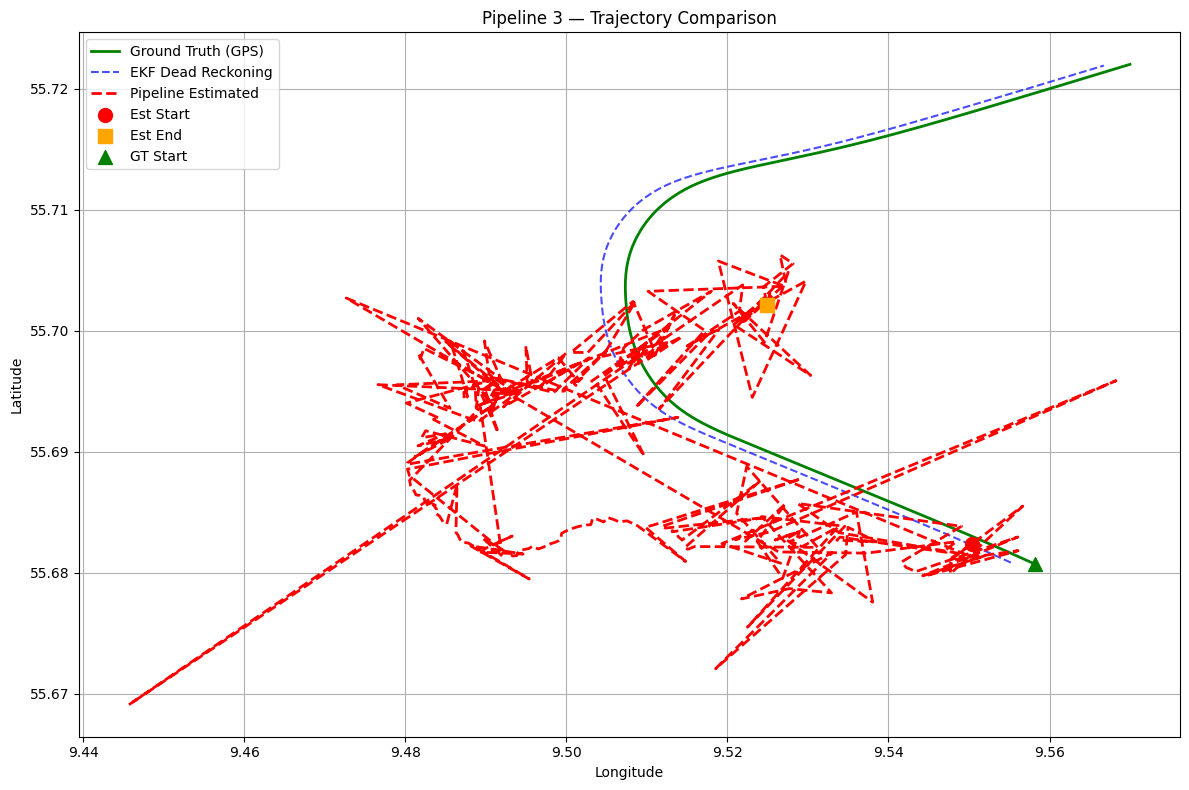

In [7]:
# Cell 7 — Visualize Trajectory
est_lats = [r['position'][0] for r in results if r.get('position') and r['position'][0]]
est_lons = [r['position'][1] for r in results if r.get('position') and r['position'][1]]
gt_lats = [imu_log.iloc[a[0]]['gps_lat'] for a in aligned]
gt_lons = [imu_log.iloc[a[0]]['gps_lon'] for a in aligned]

# Also plot EKF dead-reckoned trajectory for comparison
ekf_lats = [imu_log.iloc[a[0]]['latitude_est'] for a in aligned]
ekf_lons = [imu_log.iloc[a[0]]['longitude_est'] for a in aligned]

plt.figure(figsize=(12, 8))
plt.plot(gt_lons, gt_lats, 'g-', label='Ground Truth (GPS)', linewidth=2)
plt.plot(ekf_lons, ekf_lats, 'b--', label='EKF Dead Reckoning', linewidth=1.5, alpha=0.7)
if est_lons:
    plt.plot(est_lons, est_lats, 'r--', label='Pipeline Estimated', linewidth=2)
    plt.scatter(est_lons[0], est_lats[0], c='red', s=100, marker='o', label='Est Start', zorder=5)
    plt.scatter(est_lons[-1], est_lats[-1], c='orange', s=100, marker='s', label='Est End', zorder=5)
plt.scatter(gt_lons[0], gt_lats[0], c='green', s=100, marker='^', label='GT Start', zorder=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pipeline 3 — Trajectory Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'trajectory_comparison.png'), dpi=150)
plt.show()

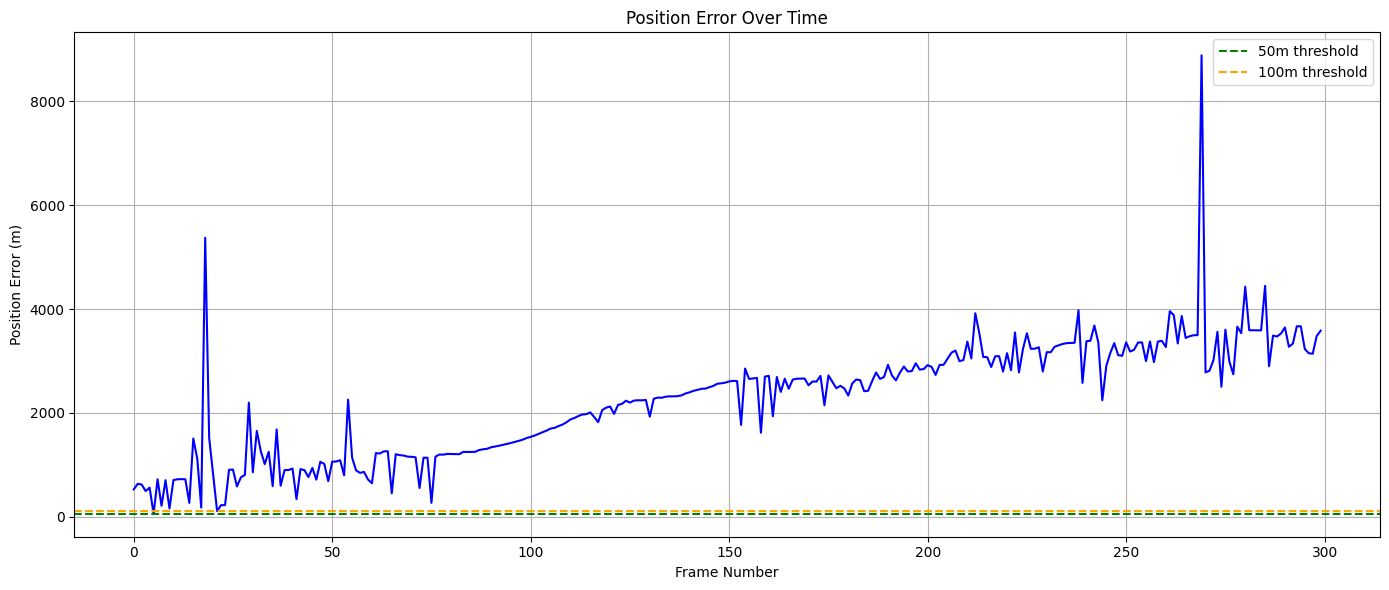

In [8]:
# Cell 8 — Error Timeline
plt.figure(figsize=(14, 6))
plt.plot(errors_arr, 'b-', linewidth=1.5)
plt.axhline(y=50, color='g', linestyle='--', label='50m threshold')
plt.axhline(y=100, color='orange', linestyle='--', label='100m threshold')
plt.xlabel('Frame Number')
plt.ylabel('Position Error (m)')
plt.title('Position Error Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'error_timeline.png'), dpi=150)
plt.show()

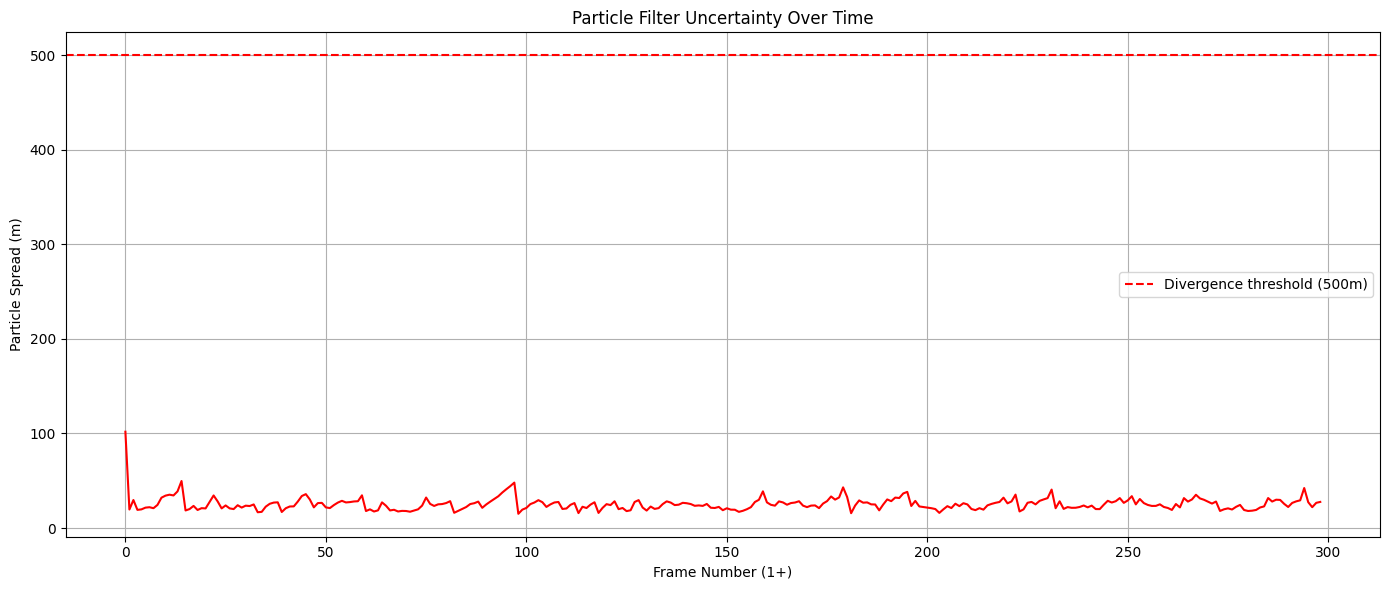


Method distribution:
  temporal_tracking        :  299 (99.7%)
  cold_start               :    1 (0.3%)

Tile matching:
  Frames with >0 tiles: 300/300 (100.0%)
  Mean tiles (when >0):  5.8
  Max tiles:             13


In [12]:
# Cell 9 — Particle Spread Analysis
spreads = [r.get('particle_spread') for r in results[1:] if r.get('particle_spread') is not None]

if spreads:
    plt.figure(figsize=(14, 6))
    plt.plot(spreads, 'r-', linewidth=1.5)
    plt.axhline(y=config.DIVERGENCE_POSITION_THRESHOLD_M, color='red', linestyle='--',
                label=f'Divergence threshold ({config.DIVERGENCE_POSITION_THRESHOLD_M:.0f}m)')
    plt.xlabel('Frame Number (1+)')
    plt.ylabel('Particle Spread (m)')
    plt.title('Particle Filter Uncertainty Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'particle_spread.png'), dpi=150)
    plt.show()
else:
    print('No particle spread data available')

# Method distribution
from collections import Counter
methods = Counter(r['method'] for r in results)
print(f'\nMethod distribution:')
for method, count in methods.most_common():
    print(f'  {method:25s}: {count:4d} ({count/len(results)*100:.1f}%)')

# Tile match statistics
tiles_tested = [r['tiles_tested'] for r in results]
tiles_nonzero = [t for t in tiles_tested if t > 0]
print(f'\nTile matching:')
print(f'  Frames with >0 tiles: {len(tiles_nonzero)}/{len(tiles_tested)} ({len(tiles_nonzero)/len(tiles_tested)*100:.1f}%)')
if tiles_nonzero:
    print(f'  Mean tiles (when >0):  {np.mean(tiles_nonzero):.1f}')
    print(f'  Max tiles:             {max(tiles_nonzero)}')

In [10]:
# Cell 10 — Performance Summary & Export
verified_count = sum(1 for r in results[1:] if r.get('meta_tile_verified', False))
sem_confs = [r.get('semantic_confidence', 0) or 0 for r in results[1:]]

valid_count = valid.sum() if valid.any() else 0
success_50 = f'{(errors_arr[valid] < 50).mean() * 100:.1f}%' if valid_count > 0 else 'N/A'
success_100 = f'{(errors_arr[valid] < 100).mean() * 100:.1f}%' if valid_count > 0 else 'N/A'

summary = {
    'Total frames': len(results),
    'Frames with position': int(valid_count),
    'Frame 0 time': f'{frame0_time:.2f}s',
    'Mean subsequent time': f'{mean_sub:.2f}s',
    'Speedup': f'{frame0_time / max(mean_sub, 0.001):.1f}x',
    'Mean error': f'{np.nanmean(errors_arr):.1f}m' if valid_count > 0 else 'N/A',
    'Median error': f'{np.nanmedian(errors_arr):.1f}m' if valid_count > 0 else 'N/A',
    'Success rate (<50m)': success_50,
    'Success rate (<100m)': success_100,
    'Meta-tile verified rate': f'{verified_count / max(len(results)-1, 1) * 100:.1f}%',
    'Mean semantic confidence': f'{np.mean(sem_confs):.3f}',
}

for key, val in summary.items():
    print(f'{key:35s}: {val}')

# Save trajectory
searcher.save_trajectory(config.TRAJECTORY_OUTPUT_DIR / 'trajectory.csv')

# Save summary
import json
with open(config.TRAJECTORY_OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nTrajectory saved to {config.TRAJECTORY_OUTPUT_DIR / "trajectory.csv"}')
print(f'Summary saved to {config.TRAJECTORY_OUTPUT_DIR / "summary.json"}')

Total frames                       : 300
Frames with position               : 300
Frame 0 time                       : 1.41s
Mean subsequent time               : 2.80s
Speedup                            : 0.5x
Mean error                         : 2236.8m
Median error                       : 2433.6m
Success rate (<50m)                : 0.0%
Success rate (<100m)               : 0.3%
Meta-tile verified rate            : 42.1%
Mean semantic confidence           : 0.227

Trajectory saved to C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\trajectories\trajectory.csv
Summary saved to C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\trajectories\summary.json
